In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
from src.feature_engineering import (
    make_feature_engineering_experiments,
    run_feature_engineering_experiments,
    plot_feature_engineering_results,
)
from sklearn.model_selection import train_test_split
from src.consts import (
    RANDOM_STATE,
    TARGET,
    DATA_PATH,
    TEST_SIZE,
    N_JOBS
)
import pandas as pd

In [19]:
df = pd.read_csv(DATA_PATH)

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [20]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

In [22]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((39073, 14), (9769, 14), (39073,), (9769,))

In [23]:
y_train.value_counts(normalize=True)

income
<=50K    0.76073
>50K     0.23927
Name: proportion, dtype: float64

In [24]:
y_test.value_counts(normalize=True)

income
<=50K    0.760672
>50K     0.239328
Name: proportion, dtype: float64

In [25]:
experiments = make_feature_engineering_experiments(
    X_train=X_train,
)

fe_results = run_feature_engineering_experiments(
    X_train=X_train,
    y_train=y_train,
    experiments=experiments,
    n_jobs=N_JOBS,
)

fe_results

,experiment,description,mean_accuracy,std_accuracy,mean_precision_macro,std_precision_macro,mean_recall_macro,std_recall_macro,mean_f1_macro,std_f1_macro,mean_roc_auc,std_roc_auc
11,combined_without_race_and_native_country,Combined features plus drop race and native-co...,0.866199,0.005073,0.835568,0.009860,0.776635,0.006861,0.799506,0.007284,0.920539,0.003657
5,drop_race,Drop race column.,0.865969,0.004412,0.835283,0.008629,0.776153,0.006217,0.799077,0.006407,0.920636,0.003186
6,capital_features,"Add capital indicators, log capital features a...",0.866045,0.004575,0.836011,0.009225,0.775508,0.006027,0.798833,0.006460,0.920428,0.003501
7,hours_features,"Add working-hours features: is_part_time, is_o...",0.866045,0.004628,0.836009,0.009276,0.775508,0.006139,0.798833,0.006562,0.920431,0.003516
9,is_us_native_country,Add binary feature is_us_native_country.,0.865943,0.004724,0.835676,0.009410,0.775587,0.006415,0.798783,0.006755,0.920432,0.003532
4,only_educational_num,Keep educational-num and drop education.,0.865994,0.004312,0.835898,0.008786,0.775474,0.005985,0.798768,0.006185,0.920577,0.003304
0,baseline_gradient_boosting,Baseline GradientBoostingClassifier without fe...,0.865917,0.004611,0.835740,0.009394,0.775424,0.005987,0.798687,0.006454,0.920390,0.003521
8,drop_native_country,Drop native-country column.,0.865738,0.004433,0.835089,0.009334,0.775672,0.005750,0.798658,0.006113,0.920632,0.003077
10,combined_reasonable_features,"Drop fnlwgt, keep educational-num, add capital...",0.865662,0.004438,0.835278,0.009080,0.775109,0.005840,0.798319,0.006236,0.920802,0.003406
2,drop_fnlwgt,Drop fnlwgt statistical weight column.,0.865508,0.004701,0.834933,0.009669,0.775044,0.005962,0.798163,0.006512,0.920756,0.003269


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Feature engineering experiments by mean_f1_macro'}, xlabel='mean_f1_macro', ylabel='experiment'>)

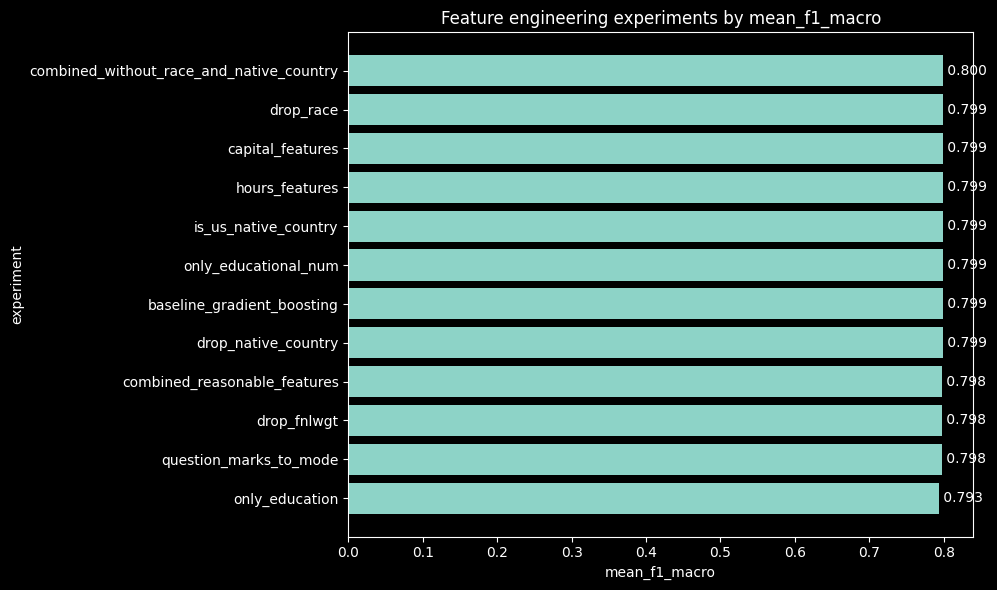

In [26]:
plot_feature_engineering_results(
    fe_results,
    metric="mean_f1_macro",
)